# UMAP Generator
This notebook is used to generate the UMAP and image mosaic of the dataset with the anchors included.
#### To do: 
Turn plot into density-based for clarity.

In [1]:
import os
import glob
from collections import defaultdict
from pathlib import Path
import pickle

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from astropy.table import vstack

from SGA.SGA import read_sga_sample
from SGA.ssl import load_ssl_embeddings
from SGA.qa import sdss_rgb

In [11]:
# ============================================================
# Configuration
# ============================================================

# SGA 2025 data
SSL_DIR = Path("/global/cfs/cdirs/desicollab/users/ioannis/SGA/2025/ssl")

REGIONS = ["dr11-south", "dr11-north"]

# Anchor classifications
ANCHOR_PATH = "/pscratch/sd/q/qshimp/VI_training/classifications/anchor_sets.csv"
ANCHOR_MODE = "rough"  # "rough" or "strict"
ANCHOR_BIN = 3

SEED = 67
rng = np.random.default_rng(SEED)

# Morphology
UNKNOWN_TYPE = 30

MORPHOLOGY_TO_TYPE = {
    "I": -5,
    "L": 0,
    "S": 10,
    "E": 20,
}

# Run information
RUN_NAME = "Large_Anchors_Full"

OUTPUT_DIR = Path("/pscratch/sd/q/qshimp/Sorter")

RUN_PATH = (OUTPUT_DIR / "binary_classifier" / RUN_NAME)
RUN_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
def load_anchor_classifications(anchor_path, mode="rough"):
    anchors = pd.read_csv(anchor_path)

    if mode == "rough":
        anchors = anchors[anchors["is_rough_anchor"]].copy()

    elif mode == "strict":
        anchors = anchors[anchors["is_strict_anchor"]].copy()

    else:
        raise ValueError(f"Unknown anchor mode: {mode!r}")

    MORPHOLOGY_TO_TYPE = {
        "I": -5,
        "L": 0,
        "S": 10,
        "E": 20,
    }

    anchors["Main_Type"] = (anchors["Morphology"].map(MORPHOLOGY_TO_TYPE))

    return {
        (str(row["Region"]), int(row["SGAID"])): int(row["Main_Type"])
        for _, row in anchors.iterrows()
        if pd.notna(row["Main_Type"])
    }

def apply_anchor_labels(subset, anchor_lookup, unknown_type=30):
    main_types = np.full(len(subset), unknown_type, dtype=np.int32)

    for i, (region, sgaid) in enumerate(zip(subset["region"], subset["SGAID"])):
        key = (str(region), int(sgaid))

        if key in anchor_lookup:
            main_types[i] = anchor_lookup[key]
    return main_types
    
# Load the main SGA2025 catalog
def load_combined_ssl_data(ssl_dir, REGIONS):
    all_data = []
    global_id_lookup = {}

    global_id = 0

    for region in REGIONS:
        catalog, _ = read_sga_sample(region=region, no_groups=True)

        region_emb = load_ssl_embeddings(region, ssl_dir, catalog)
        region_emb["region"] = region

        # Assign globally unique IDs
        region_emb["global_id"] = np.arange(global_id, global_id + len(region_emb), dtype=np.int64)

        # Build lookup
        for sgaid, gid in zip(region_emb["SGAID"], region_emb["global_id"]):
            key = (region, int(sgaid))

            if key in global_id_lookup:
                raise ValueError(f"Duplicate (region, SGAID): {key}")

            global_id_lookup[key] = int(gid)

        global_id += len(region_emb)
        all_data.append(region_emb)

    return vstack(all_data), global_id_lookup

def build_cutout_index(ssl_dir, regions, global_id_lookup):
    cutout_index = {}

    for region in regions:
        files = sorted(glob.glob(os.path.join(ssl_dir, f"ssl-cutouts-{region}-chunk*.hdf5")))

        if not files:
            raise FileNotFoundError(f"No cutout files found for {region} in {ssl_dir}")

        for fname in files:
            with h5py.File(fname, "r") as H:

                sgaids = H["sgaid"][:]

                for row, sgaid in enumerate(sgaids):
                    key = (region, int(sgaid))

                    if key not in global_id_lookup:
                        continue

                    global_id = global_id_lookup[key]

                    if global_id in cutout_index:
                        raise ValueError(f"Duplicate global_id {global_id} found while indexing cutouts")
                        
                    cutout_index[global_id] = (fname, row)

    return cutout_index

In [4]:
# Display a 2-D scatter plot where each grid cell shows a representative galaxy.
def scatter_plot_as_images(coords_2d, global_ids, cutout_index, nx=8, ny=8, npix_show=96, seed=None):
    coords = np.asarray(coords_2d)[:, :2]
    global_ids = np.asarray(global_ids)

    rng_loc = np.random.default_rng(seed)

    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()

    binx = np.linspace(xmin, xmax, nx + 1)
    biny = np.linspace(ymin, ymax, ny + 1)

    ix_bins = np.clip(np.digitize(coords[:, 0], binx) - 1, 0, nx - 1)
    iy_bins = np.clip(np.digitize(coords[:, 1], biny) - 1, 0, ny - 1)

    # Pick one globally unique ID per non-empty bin
    picks = {}

    for ix in range(nx):
        for iy in range(ny):
            in_bin = global_ids[(ix_bins == ix) & (iy_bins == iy)]

            if len(in_bin):
                picks[(ix, iy)] = int(rng_loc.choice(in_bin))

    # Batch HDF5 reads by file
    file_entries = defaultdict(list)

    for (ix, iy), global_id in picks.items():
        if global_id not in cutout_index:
            print(f"Warning: global ID {global_id} not found in cutout index")
            continue

        fname, row = cutout_index[global_id]
        file_entries[fname].append((ix, iy, row, global_id))

    margin = max(0, (152 - npix_show) // 2)
    canvas = np.ones((ny * npix_show, nx * npix_show, 3), np.float32)
    picked_global_ids = []

    for fname, entries in file_entries.items():
        with h5py.File(fname, 'r') as H:
            for ix, iy, row, global_id in entries:
                img = H['images'][row]
                rgb = sdss_rgb([img[0], img[1], img[2]], ['g', 'r', 'z'])
                thumb = rgb[margin:margin + npix_show, margin:margin + npix_show]
                canvas[iy * npix_show:(iy + 1) * npix_show, ix * npix_show:(ix + 1) * npix_show] = thumb
                picked_global_ids.append(global_id)

    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)   
    ax.imshow(canvas, origin="lower", interpolation="none") 
    ax.axis("off") 
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    
    return canvas, picked_global_ids

In [5]:
# Load SGA2025 catalog + SSL embeddings
data, global_id_lookup = load_combined_ssl_data(SSL_DIR, REGIONS)
print(f"Loaded {len(data):,d} SGA2025 galaxies")

# Build SGA2025 cutout index
print("Building SGA2025 cutout index...")
cutout_index = build_cutout_index(SSL_DIR, REGIONS, global_id_lookup)
print(f"Indexed {len(cutout_index):,d} SGA2025 cutouts")

# Load anchor classifications
anchor_lookup = load_anchor_classifications(ANCHOR_PATH, mode=ANCHOR_MODE)
print(f"Loaded {len(anchor_lookup):,d} {ANCHOR_MODE} anchor classifications")

INFO:SGA.py:363:_read_catalog: Read 395,435/395,435 GROUP_PRIMARY objects from /dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-south.fits
INFO:SGA.py:370:_read_catalog: Selecting 395,435/395,435 objects in region=dr11-south
INFO:ssl.py:323:load_ssl_embeddings: load_ssl_embeddings: 363,607 objects from /global/cfs/cdirs/desicollab/users/ioannis/SGA/2025/ssl/ssl-embeddings-dr11-south.hdf5
INFO:SGA.py:363:_read_catalog: Read 90,504/90,504 GROUP_PRIMARY objects from /dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-north.fits
INFO:SGA.py:370:_read_catalog: Selecting 90,504/90,504 objects in region=dr11-north
INFO:ssl.py:323:load_ssl_embeddings: load_ssl_embeddings: 82,086 objects from /global/cfs/cdirs/desicollab/users/ioannis/SGA/2025/ssl/ssl-embeddings-dr11-north.hdf5
Loaded 445,693 SGA2025 galaxies
Building SGA2025 cutout index...
Indexed 445,693 SGA2025 cutouts
Loaded 868 strict anchor classifications


In [12]:
# Select SGA2025 subset

rng = np.random.default_rng(SEED)

mask = np.ones(len(data), dtype=bool)  # start with the full sample

# Diameter range:
# 119.472 arcsec = 1.9912 arcmin
# 159.296 arcsec = 2.6549 arcmin

#mask = ((data["D26"] > 119.472 / 60) & (data["D26"] <= 159.296 / 60))

subset = data[mask]

print(f"Keeping {len(subset):,d} / {len(data):,d} galaxies ({100 * len(subset) / len(data):.1f}%)")


# Optional random subsample
N_SUBSAMPLE = 500_000

if len(subset) > N_SUBSAMPLE:

    idx = rng.choice(len(subset), size=N_SUBSAMPLE, replace=False)
    subset = subset[idx]

print(f"Working with {len(subset):,d} galaxies")

# Apply anchor morphology labels
subset_main_types = apply_anchor_labels(subset, anchor_lookup, unknown_type=UNKNOWN_TYPE)

print(f"Assigned known morphology to {np.sum(subset_main_types != UNKNOWN_TYPE):,d} galaxies")
print(f"Remaining Unknown: {np.sum(subset_main_types == UNKNOWN_TYPE):,d}")

# Prepare embeddings
emb = np.asarray(subset["embeddings"])

assert len(emb) == len(subset)
assert len(subset_main_types) == len(subset)

# Run UMAP
N_NEIGHBORS = 10
MIN_DIST = 0.1
METRIC = "cosine"

print(
    f"Running UMAP "
    f"(n_neighbors={N_NEIGHBORS}, "
    f"min_dist={MIN_DIST}, "
    f"metric={METRIC!r})..."
)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    metric=METRIC,
    random_state=seed,
    low_memory=True,
    n_jobs=1,
    verbose=True
)

umap_coords = reducer.fit_transform(emb)

print("Done.")
print(f"UMAP coordinates shape: {umap_coords.shape}")

Keeping 445,693 / 445,693 galaxies (100.0%)
Working with 445,693 galaxies
Assigned known morphology to 868 galaxies
Remaining Unknown: 444,825
Running UMAP (n_neighbors=10, min_dist=0.1, metric='cosine')...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=10, random_state=42, verbose=True)
Wed Jul 22 05:09:04 2026 Construct fuzzy simplicial set
Wed Jul 22 05:09:09 2026 Finding Nearest Neighbors
Wed Jul 22 05:09:10 2026 Building RP forest with 38 trees
Wed Jul 22 05:11:10 2026 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	Stopping threshold met -- exiting after 2 iterations
Wed Jul 22 05:13:10 2026 Finished Nearest Neighbor Search
Wed Jul 22 05:13:17 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 22 05:17:25 2026 Finished embedding
Done.
UMAP coordinates shape: (445693, 2)


In [13]:
# Save bridge artifact for the classifier notebook
bridge_run_path = OUTPUT_DIR / "binary_classifier" / RUN_NAME
bridge_run_path.mkdir(parents=True, exist_ok=True)
bridge_path = bridge_run_path / "merged_artifacts.npz"
np.savez(
    bridge_path,
    targetid=np.asarray(subset["global_id"]),
    ra=np.asarray(subset["RA"]),
    dec=np.asarray(subset["DEC"]),
    embeddings=emb,
    umap_embeddings=umap_coords,
    Main_Type=subset_main_types,
)
print(f"Saved bridge artifact ({len(subset):,d} galaxies) to {bridge_path}")

Saved bridge artifact (445,693 galaxies) to /pscratch/sd/q/qshimp/Sorter/binary_classifier/Large_Anchors_Full/merged_artifacts.npz


Creating morphology UMAP...
Saved morphology UMAP PDF: /pscratch/sd/q/qshimp/Sorter/binary_classifier/Large_Anchors_Full/plots/umap_morphology_rough_445693galaxies.pdf
Saved morphology UMAP PNG: /pscratch/sd/q/qshimp/Sorter/binary_classifier/Large_Anchors_Full/plots/umap_morphology_rough_445693galaxies.png


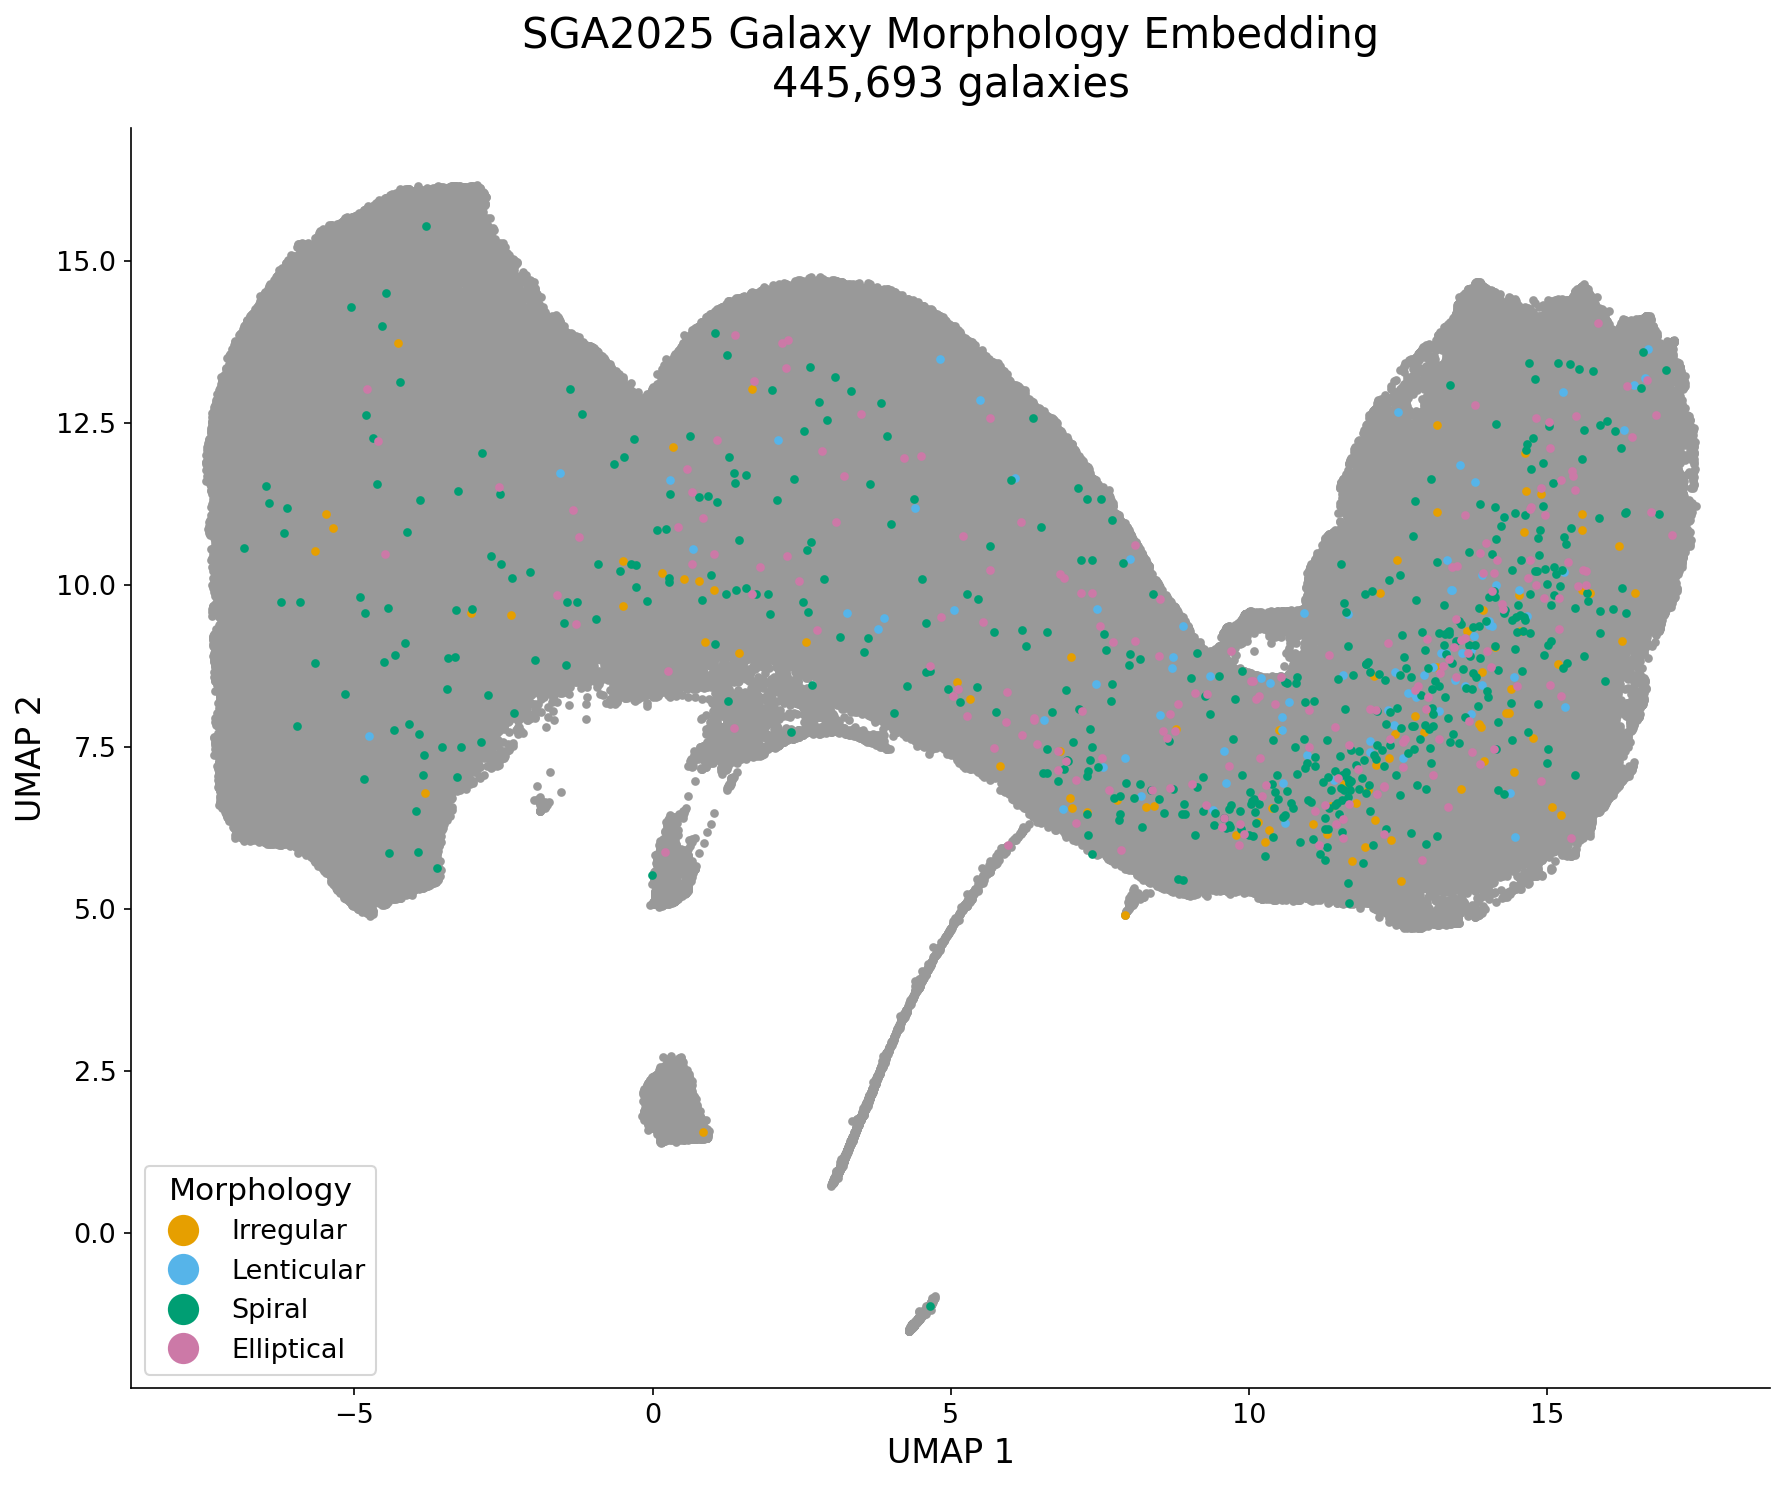

Saved mosaic PNG: /pscratch/sd/q/qshimp/Sorter/binary_classifier/Large_Anchors_Full/plots/umap_mosaic_rough_445693galaxies.png


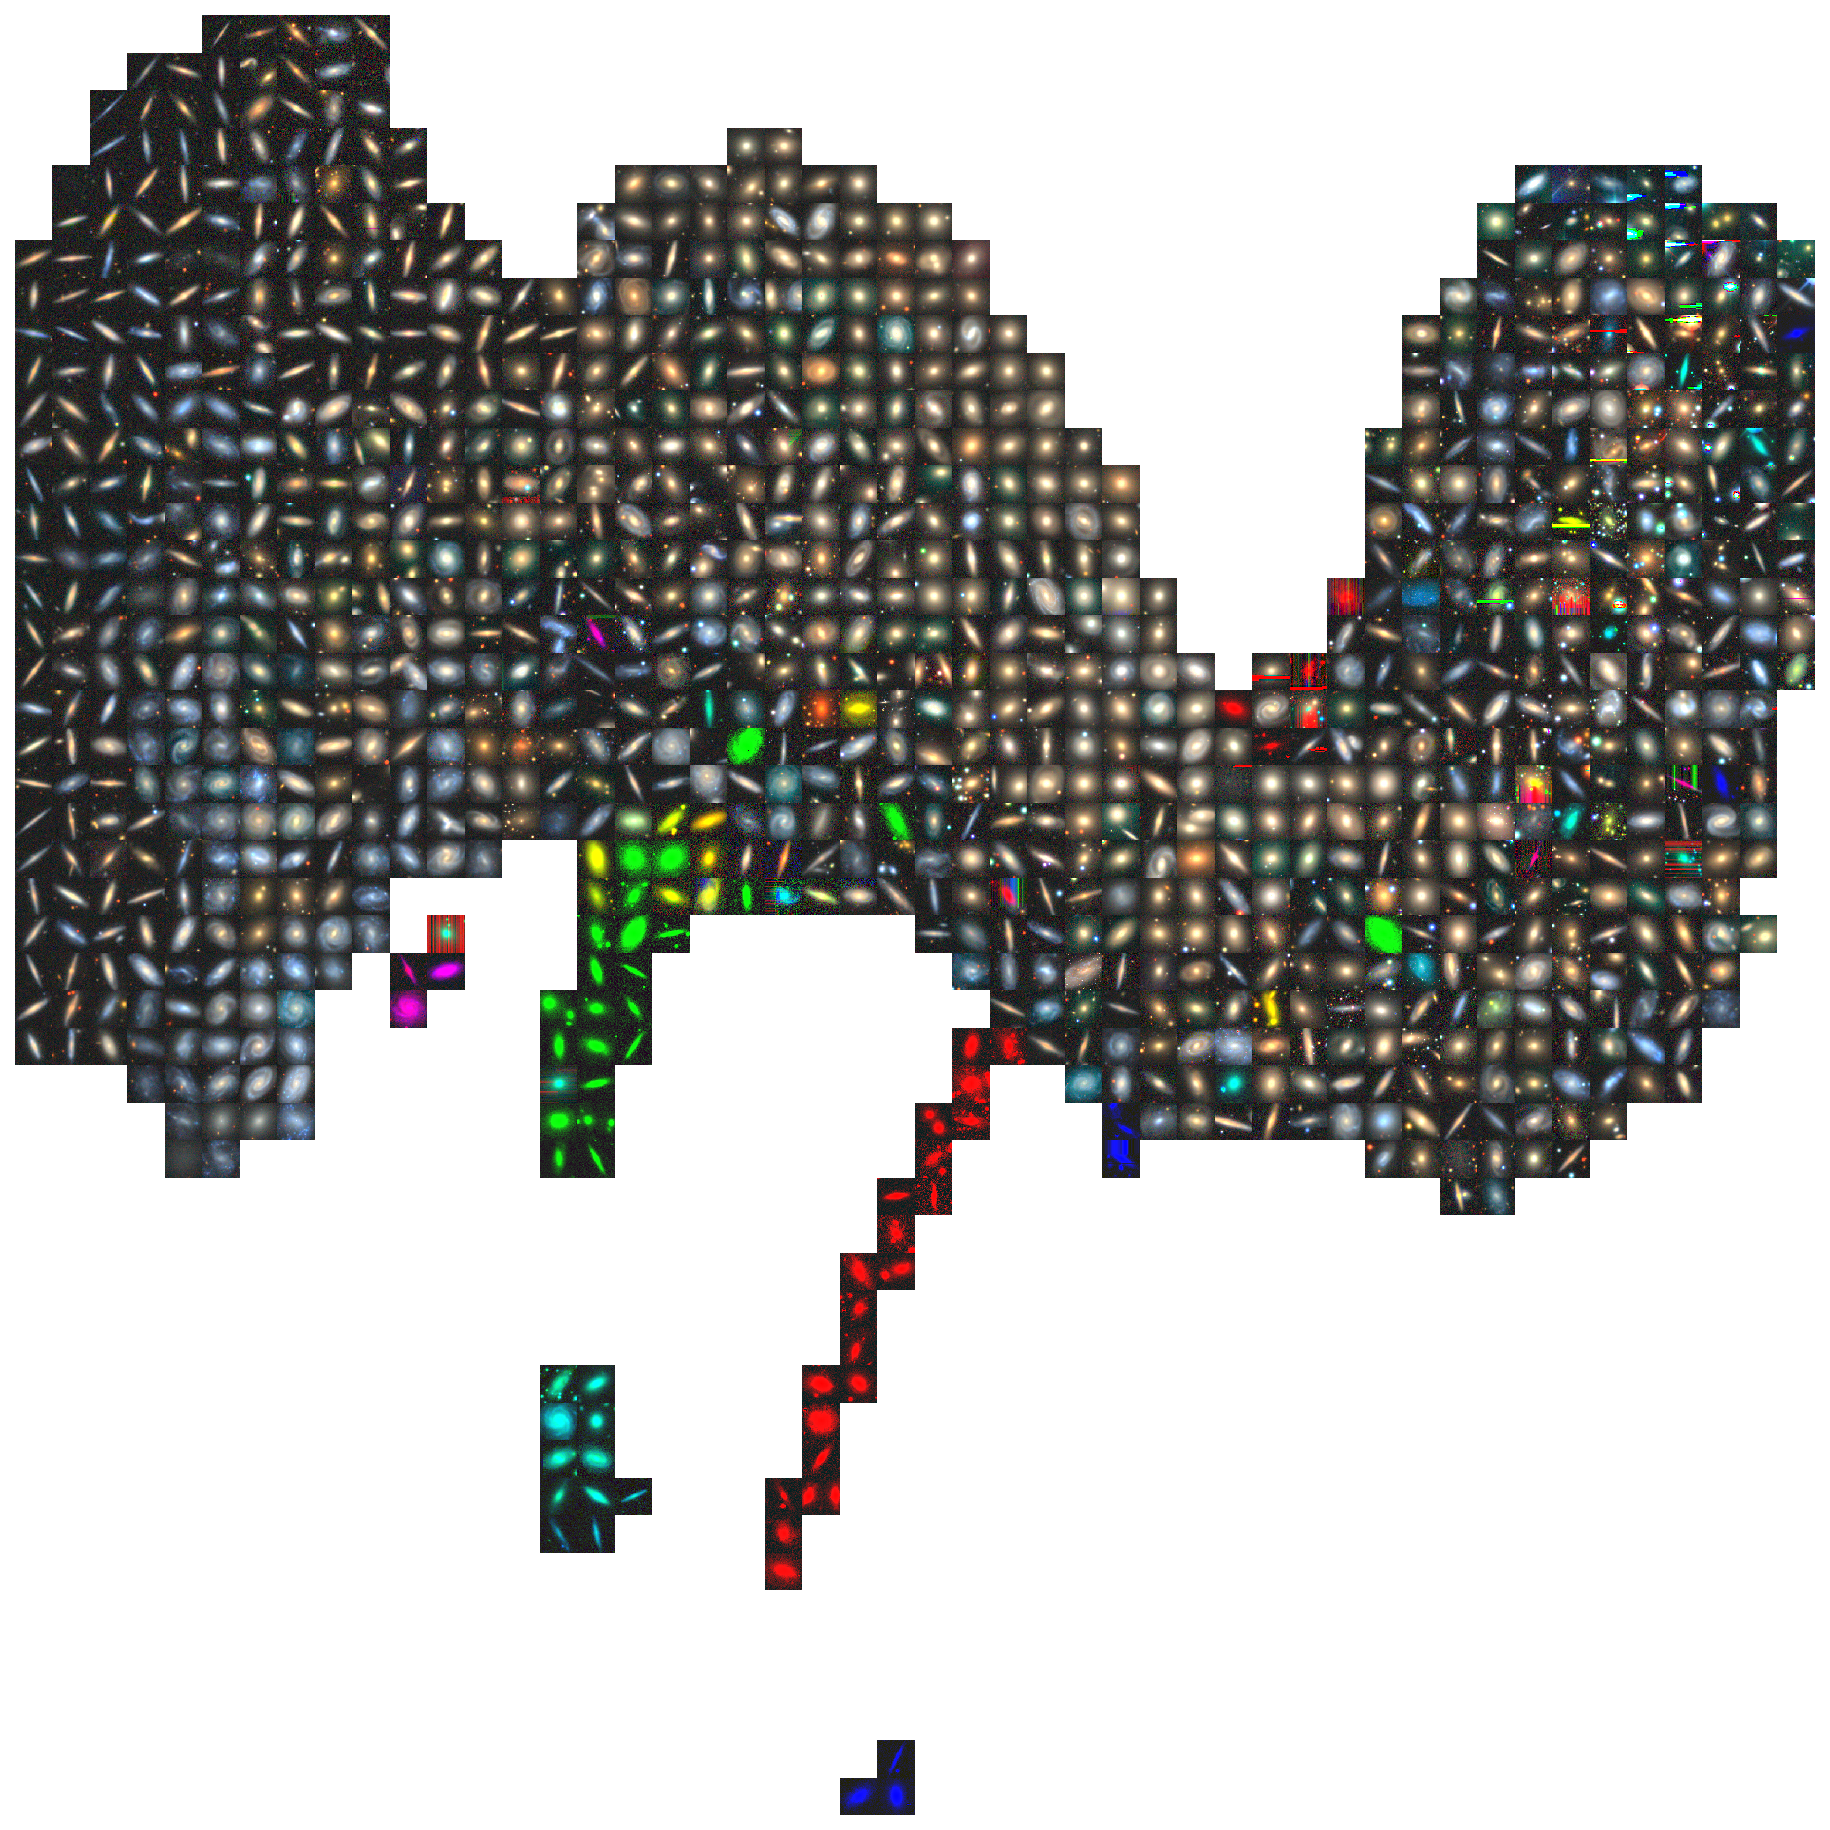

In [14]:
# Plot UMAP colored by morphology
MORPHOLOGY_COLORS = {
    -5: "#E69F00",  # Irregular — orange
     0: "#56B4E9",  # Lenticular — sky blue
    10: "#009E73",  # Spiral — green
    20: "#CC79A7",  # Elliptical — magenta
}

MORPHOLOGY_LABELS = {
    -5: "Irregular",
     0: "Lenticular",
    10: "Spiral",
    20: "Elliptical",
    30: "Unknown"
}

print("Creating morphology UMAP...")

fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

unknown_color = "#999999"
unknown_mask = subset_main_types == 30

ax.scatter(
    umap_coords[unknown_mask, 0],
    umap_coords[unknown_mask, 1],
    c=unknown_color,
    s=10,
    rasterized=True,
    zorder=1
)

for main_type, color in MORPHOLOGY_COLORS.items():

    type_mask = subset_main_types == main_type

    if not np.any(type_mask):
        continue

    ax.scatter(
        umap_coords[type_mask, 0],
        umap_coords[type_mask, 1],
        c=color,
        s=10,
        rasterized=True,
        zorder=2
    )

# Legend
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color,
        markeredgecolor="none",
        markersize=10,
        label=MORPHOLOGY_LABELS[main_type]
    )
    for main_type, color in MORPHOLOGY_COLORS.items()
]

ax.legend(
    handles=legend_handles,
    title="Morphology",
    fontsize=13,
    title_fontsize=15,
    markerscale=1.5,
    loc="best",
    frameon=True
)

ax.set_xlabel("UMAP 1", fontsize=16)
ax.set_ylabel("UMAP 2", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=13)

ax.set_title(
    f"SGA2025 Galaxy Morphology Embedding\n"
    f"{len(subset):,} galaxies",
    fontsize=20,
    pad=15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

# Save files
PLOT_DIR = RUN_PATH / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

morphology_pdf = (PLOT_DIR / f"umap_morphology_{ANCHOR_MODE}_{len(subset)}galaxies.pdf")
morphology_png = (PLOT_DIR / f"umap_morphology_{ANCHOR_MODE}_{len(subset)}galaxies.png")

fig.savefig(morphology_pdf, bbox_inches="tight", pad_inches=0.05)
fig.savefig(morphology_png, dpi=600, bbox_inches="tight", pad_inches=0.05)

print(f"Saved morphology UMAP PDF: {morphology_pdf}")
print(f"Saved morphology UMAP PNG: {morphology_png}")

plt.show()
plt.close(fig)

# Save UMAP image mosaic
canvas, picked = scatter_plot_as_images(
    umap_coords,
    subset["global_id"],
    cutout_index,
    nx=48,
    ny=48,
    npix_show=64,
    seed=seed
)

mosaic_png = (PLOT_DIR / f"umap_mosaic_{ANCHOR_MODE}_{len(subset)}galaxies.png")
plt.imsave(mosaic_png, canvas)
print(f"Saved mosaic PNG: {mosaic_png}")